# 逻辑回归：乳腺癌二分类

本教程使用 scikit-learn 内置的 Breast Cancer Wisconsin 数据集，
构建一个可复现的二分类流程。数据无需联网下载。

> **标签约定：** scikit-learn 原始标签中 `0 = malignant`、
> `1 = benign`。为了让评估指标直接回答“能否识别恶性样本”，
> 本教程重新编码为 **`malignant = 1`（正类）**、
> **`benign = 0`（负类）**。

该示例仅用于统计学习教学，不能替代医疗诊断。

## Goal

完成本教程后，你将能够：

- 从 `sklearn.datasets.load_breast_cancer` 加载内置示例数据；
- 明确二分类中的正类，并用分层抽样划分训练集和测试集；
- 用 `StandardScaler` 与 `LogisticRegression` 组成无数据泄漏的 Pipeline；
- 计算 accuracy、precision、recall、F1 和 ROC AUC；
- 阅读混淆矩阵、ROC 曲线和标准化特征对应的模型系数；
- 用完整性断言和简单基线检查结果是否合理。

## Setup

需要 Python 3，以及 `numpy`、`pandas`、`matplotlib` 和
`scikit-learn`。第一行魔法命令让 Matplotlib 图表直接显示在
Jupyter Notebook 中。

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.9.0


## Steps

### 1. 加载数据并重新编码目标变量

`as_frame=True` 让特征和标签直接以 pandas 对象返回。除目标变量
的清晰重编码外，不对内置数据做人工修改。

In [2]:
breast_cancer = load_breast_cancer(as_frame=True)

features = breast_cancer.data.copy()
target = (breast_cancer.target == 0).astype("int64").rename("malignant")
modeling_data = features.assign(malignant=target)

target_mapping = pd.DataFrame(
    {
        "Original sklearn target": [0, 1],
        "Original label": breast_cancer.target_names,
        "Tutorial target": [1, 0],
        "Tutorial meaning": ["Malignant (positive)", "Benign (negative)"],
    }
)

print(f"Rows: {modeling_data.shape[0]}")
print(f"Predictor columns: {features.shape[1]}")
display(target_mapping)
display(modeling_data.head())

Rows: 569
Predictor columns: 30


,Original sklearn target,Original label,Tutorial target,Tutorial meaning
0,0,malignant,1,Malignant (positive)
1,1,benign,0,Benign (negative)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 2. 检查数据完整性与类别分布

先确认缺失值数量、目标类别和类别比例。类别分布不完全均衡，
因此后续切分使用 `stratify=target`。

In [3]:
data_quality = pd.Series(
    {
        "Total missing predictor values": int(features.isna().sum().sum()),
        "Duplicate rows": int(modeling_data.duplicated().sum()),
        "Number of target classes": int(target.nunique()),
    },
    name="Value",
).to_frame()

class_balance = (
    target.value_counts()
    .sort_index()
    .rename(index={0: "Benign (0)", 1: "Malignant (1)"})
    .rename("Count")
    .to_frame()
)
class_balance["Proportion"] = class_balance["Count"] / len(target)

display(data_quality)
display(class_balance.style.format({"Proportion": "{:.2%}"}))

,Value
Total missing predictor values,0
Duplicate rows,0
Number of target classes,2


,Count,Proportion
malignant,,
Benign (0),357,62.74%
Malignant (1),212,37.26%


### 3. 分层划分训练集和测试集

测试集占 20%。`random_state=42` 固定抽样结果，`stratify=target`
使两个子集尽量保持相同的恶性/良性比例。测试集只用于最终评估。

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)

split_balance = pd.DataFrame(
    {
        "Train": y_train.value_counts(normalize=True).sort_index(),
        "Test": y_test.value_counts(normalize=True).sort_index(),
    }
).rename(index={0: "Benign (0)", 1: "Malignant (1)"})

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
display(split_balance.style.format("{:.2%}"))

Training rows: 455
Test rows: 114


,Train,Test
malignant,,
Benign (0),62.64%,63.16%
Malignant (1),37.36%,36.84%


### 4. 建立并训练 Pipeline

逻辑回归对特征尺度敏感。Pipeline 会先用**训练集**估计均值与
标准差，再拟合逻辑回归；同样的变换随后应用到测试集，从而避免
将测试集信息泄漏到训练过程。

In [5]:
logistic_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully.")

Pipeline fitted successfully.


### 5. 计算测试集指标

以下指标都以 `malignant = 1` 为正类：

- **Accuracy**：所有预测中正确预测的比例；
- **Precision**：预测为恶性的样本中，实际恶性的比例；
- **Recall**：实际恶性样本中，被模型识别出的比例；
- **F1**：precision 与 recall 的调和平均；
- **ROC AUC**：跨越不同分类阈值时的排序能力。

医疗筛查中漏掉恶性样本（假阴性）的代价通常很高，因此不能只看
accuracy；本教程同时报告 recall 和混淆矩阵。

In [6]:
y_pred = logistic_pipeline.predict(X_test)
positive_class_index = np.flatnonzero(logistic_pipeline.classes_ == 1).item()
y_score = logistic_pipeline.predict_proba(X_test)[:, positive_class_index]

metric_values = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    "Recall": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
    "F1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_score),
}
metrics_table = pd.Series(metric_values, name="Test score").to_frame()

display(metrics_table.style.format("{:.4f}"))

,Test score
Accuracy,0.9649
Precision,0.9750
Recall,0.9286
F1,0.9512
ROC AUC,0.9960


### 6. 绘制混淆矩阵

行表示真实类别，列表示预测类别。右上角是把良性误报为恶性的
假阳性，左下角是把恶性漏判为良性的假阴性。

,Predicted Benign (0),Predicted Malignant (1)
Actual Benign (0),71,1
Actual Malignant (1),3,39


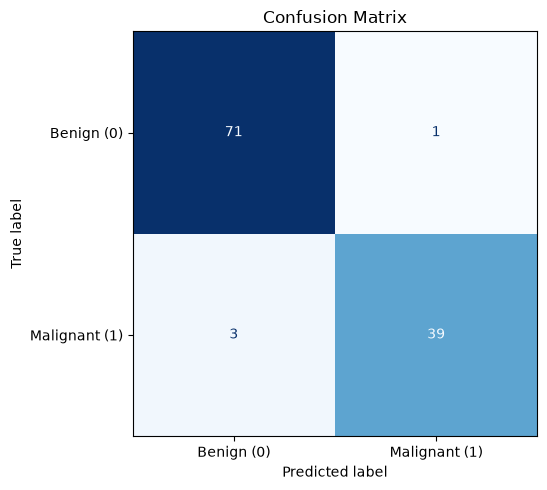

In [7]:
confusion = confusion_matrix(y_test, y_pred, labels=[0, 1])
confusion_table = pd.DataFrame(
    confusion,
    index=["Actual Benign (0)", "Actual Malignant (1)"],
    columns=["Predicted Benign (0)", "Predicted Malignant (1)"],
)
display(confusion_table)

figure, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Benign (0)", "Malignant (1)"],
).plot(ax=axis, cmap="Blues", colorbar=False)
axis.set_title("Confusion Matrix")
figure.tight_layout()
plt.show()

### 7. 绘制 ROC 曲线

ROC 曲线展示分类阈值变化时真正率与假正率之间的权衡。虚线表示
随机排序基准；曲线越靠近左上角，整体区分能力越强。

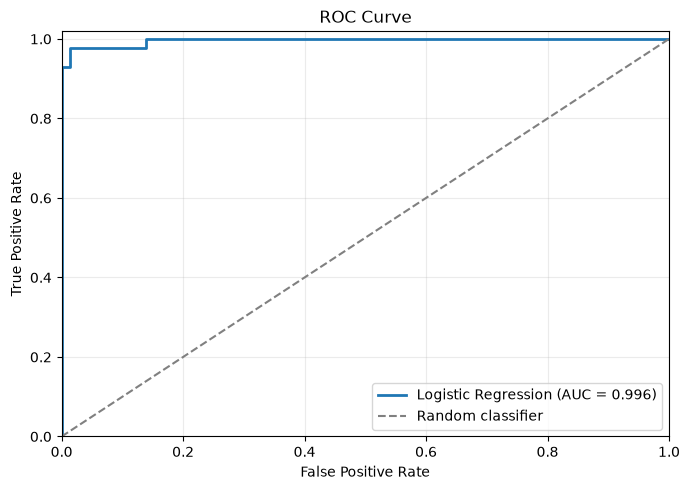

In [8]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    y_score,
    pos_label=1,
)

figure, axis = plt.subplots(figsize=(7, 5))
axis.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"Logistic Regression (AUC = {metric_values['ROC AUC']:.3f})",
)
axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)
axis.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curve",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axis.grid(alpha=0.25)
axis.legend(loc="lower right")
figure.tight_layout()
plt.show()

### 8. 查看系数方向与大小

因为所有特征先经过标准化，系数可以在相同尺度上做粗略比较。
正系数提高模型预测“恶性”的对数几率，负系数降低该对数几率。
相关特征之间会共享或抵消权重，所以系数不应被解释为因果效应。

,Feature,Coefficient,Absolute coefficient
14,worst texture,1.4341,1.4341
13,radius error,1.2333,1.2333
12,worst symmetry,1.0613,1.0613
11,mean concave points,0.9528,0.9528
10,worst concavity,0.9114,0.9114
9,area error,0.9090,0.9090
0,compactness error,-0.9069,0.9069
8,worst area,0.9005,0.9005
7,worst radius,0.8970,0.8970
6,mean concavity,0.7823,0.7823


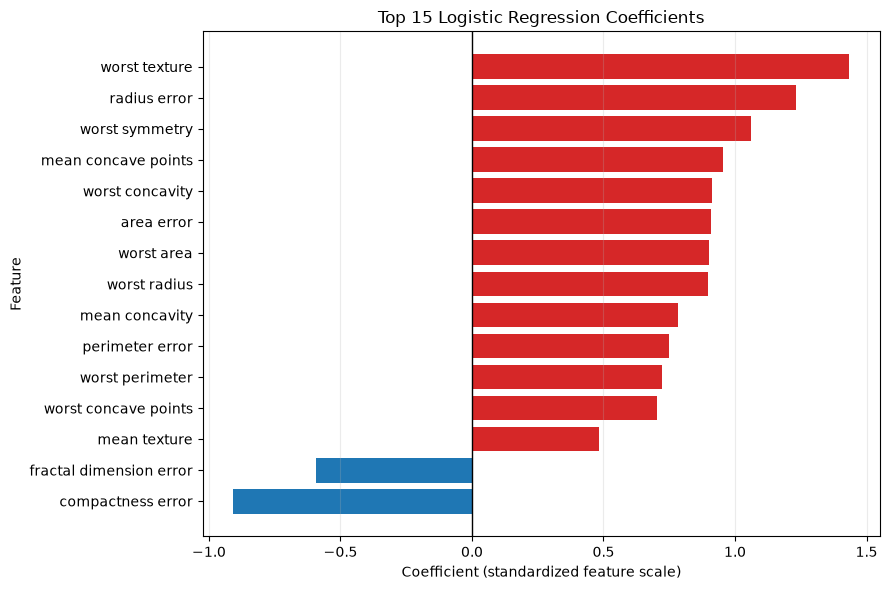

In [9]:
coefficients = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Coefficient": logistic_pipeline.named_steps[
            "classifier"
        ].coef_[0],
    }
)
coefficients["Absolute coefficient"] = coefficients["Coefficient"].abs()
top_coefficients = (
    coefficients.nlargest(15, "Absolute coefficient")
    .sort_values("Coefficient")
    .reset_index(drop=True)
)

display(
    top_coefficients.sort_values(
        "Absolute coefficient",
        ascending=False,
    ).style.format(
        {
            "Coefficient": "{:.4f}",
            "Absolute coefficient": "{:.4f}",
        }
    )
)

bar_colors = np.where(
    top_coefficients["Coefficient"] >= 0,
    "tab:red",
    "tab:blue",
)
figure, axis = plt.subplots(figsize=(9, 6))
axis.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"],
    color=bar_colors,
)
axis.axvline(0, color="black", linewidth=1)
axis.set(
    xlabel="Coefficient (standardized feature scale)",
    ylabel="Feature",
    title="Top 15 Logistic Regression Coefficients",
)
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
plt.show()

## Checks

### 完整性与可复现性检查

这些断言验证数据、切分、预测概率、指标和混淆矩阵之间的一致性。
如果上游代码被意外修改，Notebook 会尽早给出明确错误。

In [10]:
assert features.shape == (569, 30)
assert int(features.isna().sum().sum()) == 0
assert set(target.unique()) == {0, 1}
assert int(target.sum()) == 212, "Malignant samples should be the positive class."

assert X_train.index.is_unique and X_test.index.is_unique
assert X_train.index.intersection(X_test.index).empty
assert len(X_train) + len(X_test) == len(features)
assert abs(y_train.mean() - y_test.mean()) < 0.02

assert set(np.unique(y_pred)).issubset({0, 1})
assert np.all((0.0 <= y_score) & (y_score <= 1.0))
assert confusion.sum() == len(y_test)
assert all(0.0 <= value <= 1.0 for value in metric_values.values())

print("All integrity checks passed.")

All integrity checks passed.


### 与多数类基线比较

`DummyClassifier` 总是预测训练集中的多数类。它不能解决任务，但能
帮助判断逻辑回归是否学到了比“永远猜多数类”更多的信息。

In [11]:
majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(X_train, y_train)
baseline_pred = majority_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

accuracy_comparison = pd.DataFrame(
    {
        "Model": ["Majority baseline", "Logistic regression"],
        "Test accuracy": [
            baseline_accuracy,
            metric_values["Accuracy"],
        ],
    }
)

display(accuracy_comparison.style.format({"Test accuracy": "{:.4f}"}))
assert metric_values["Accuracy"] > baseline_accuracy
print("Logistic regression outperforms the majority-class baseline.")

,Model,Test accuracy
0,Majority baseline,0.6316
1,Logistic regression,0.9649


Logistic regression outperforms the majority-class baseline.


## Next Steps

可以在这个可复现基线之上继续探索：

1. 用交叉验证调整正则化参数 `C`，并把调参限制在训练集内；
2. 根据假阴性与假阳性的业务代价选择分类阈值，而不是固定使用 0.5；
3. 检查 precision-recall 曲线和概率校准；
4. 用重复交叉验证报告指标的不确定性；
5. 比较不同正则化方式或其他分类器，但保留独立测试集用于最终评估。

若用于真实医疗场景，还需要外部验证、数据漂移监控、公平性评估、
临床专家审查与合规流程。